# Solutions

:::{admonition} Reference solutions
:class: note
Worked solutions for the short exercises in [1.8-statistical-foundations-and-ml-exercises.ipynb](1.8-statistical-foundations-and-ml-exercises.ipynb).
:::

## Exercise 1: Explore

Build a DataFrame of 60 stations with `elevation_m` uniform on [200, 3500] and `temp_celsius = 15 - 6.5 * elevation_m/1000 + noise` (noise standard deviation 1.5 °C, seeded). Make a seaborn regression plot of temperature against elevation and print `describe()`.

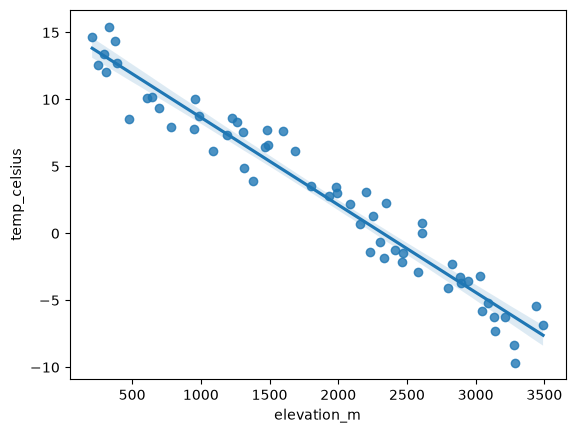

       elevation_m  temp_celsius
count        60.00         60.00
mean       1867.55          2.99
std         987.31          6.63
min         209.04         -9.66
25%        1065.20         -2.44
50%        1990.39          3.03
75%        2655.25          8.03
max        3490.79         15.43


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)
elev = rng.uniform(200, 3500, 60)
temp = 15 - 6.5 * (elev / 1000) + rng.normal(0, 1.5, 60)
df = pd.DataFrame({"elevation_m": elev, "temp_celsius": temp})
sns.regplot(data=df, x="elevation_m", y="temp_celsius")
plt.show()
print(df.describe().round(2))

## Exercise 2: Correlation

Print the Pearson correlation matrix of the DataFrame and identify the sign of the temperature–elevation correlation.

In [ ]:
print(df.corr().round(3))   # temperature vs elevation is strongly negative (the lapse rate)

              elevation_m  temp_celsius
elevation_m         1.000        -0.973
temp_celsius       -0.973         1.000


## Exercise 3: Fit a linear regression

Fit `LinearRegression` with `X = df[["elevation_m"]]` and `y = df["temp_celsius"]`. Print the recovered lapse rate in °C km⁻¹ and the intercept.

In [ ]:
from sklearn.linear_model import LinearRegression
X = df[["elevation_m"]]; y = df["temp_celsius"]
m = LinearRegression().fit(X, y)
print(round(m.coef_[0] * 1000, 2), "°C km^-1")
print(round(m.intercept_, 2), "°C")

-6.53 °C km^-1
15.18 °C


## Exercise 4: Honest evaluation

Split the data (test size 0.3, fixed random state), fit on the training set, and report the test RMSE and R^2.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
m = LinearRegression().fit(Xtr, ytr)
p = m.predict(Xte)
print("RMSE:", round(root_mean_squared_error(yte, p), 3))
print("R^2: ", round(r2_score(yte, p), 3))

RMSE: 1.35
R^2:  0.962


## Exercise 5: Multivariate regression on real advertising data

The data cached at `path` below (fetched by the pre-supplied cell) holds real advertising spend and sales for 200 markets: `TV`, `Radio`, and `Newspaper` budgets (thousands of dollars) and `Sales` (thousands of units) — the classic dataset behind the "which channel actually drives sales" question (James et al., *An Introduction to Statistical Learning*).

1. Load the CSV. Build `X` from all three budget columns and `y` from `Sales`.
2. Split into train and test sets (test size 0.3, fixed random state), fit a `LinearRegression`, and print the three coefficients alongside their column names.
3. Report the test RMSE and R^2. Which budget has the largest coefficient? Before concluding that channel is the most effective, what would you need to check about the three columns' scales?

In [ ]:
# Pre-supplied: download the data file and cache it locally.
# You do not need to understand this cell yet — fetching data is covered in the
# reproducible-data-pipelines bonus subchapter.
import pooch

path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/Advertising.csv",
    known_hash="sha256:69104adc017e75d7019f61fe66ca2eb4ab014ee6f2a9b39b452943f209352010",
    fname="advertising.csv",
    path=pooch.os_cache("mlees"),
)
ads = pd.read_csv(path)
X_ads = ads[["TV", "Radio", "Newspaper"]]
y_ads = ads["Sales"]

Xtr_ads, Xte_ads, ytr_ads, yte_ads = train_test_split(X_ads, y_ads, test_size=0.3, random_state=0)
model_ads = LinearRegression().fit(Xtr_ads, ytr_ads)

for name, coef in zip(X_ads.columns, model_ads.coef_):
    print(name, round(coef, 4))

pred_ads = model_ads.predict(Xte_ads)
print("RMSE:", round(root_mean_squared_error(yte_ads, pred_ads), 3))
print("R^2: ", round(r2_score(yte_ads, pred_ads), 3))

# the three budgets are on very different scales (TV runs into the hundreds, newspaper is
# smaller), so a larger raw coefficient does not automatically mean a larger effect -- fit
# on standardized features (as in the pipeline below) before ranking channels this way

TV 0.0439
Radio 0.2003
Newspaper 0.0018
RMSE: 1.921
R^2:  0.865


## Exercise 6: A pipeline with scaling

Build a `Pipeline` of `StandardScaler` followed by `LinearRegression`, fit it on the training set, and print its test R^2 (via `.score`).

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
pipe = make_pipeline(StandardScaler(), LinearRegression()).fit(Xtr, ytr)
print(round(pipe.score(Xte, yte), 3))

0.962


## Exercise 7: Demonstrate overfitting

Fit a degree-8 polynomial pipeline and compare its R^2 on training data with its R^2 on test data. `elevation_m` is in metres (order 10^2-10^3); an 8th-degree polynomial built directly on raw metres is numerically unstable rather than overfit, so rescale it to kilometres first (divide by 1000) — the same rescaling the lecture's own degree-8 demonstration relies on. A degree-8 polynomial has 9 parameters: fit on the full 42-point training set from Exercise 4, it is heavily over-determined and generalises fine instead of overfitting. Fit it on only the first 12 rows of the (already-shuffled) training set instead, matching the near-saturated regime — 12 points for 9 parameters — the lecture's own demonstration uses. Comment on the gap.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# elevation_m is in metres (order 1e3); an 8th-degree polynomial built directly on raw
# metres is numerically ill-conditioned rather than overfit, so rescale to kilometres
# first — the same fix the lecture's own degree-8 demonstration relies on
Xtr_km, Xte_km = Xtr / 1000, Xte / 1000

# shrinking the training set alone (down to 9-12 points) only produces a mild gap here,
# because the elevations are scattered randomly across the full range rather than evenly
# spaced -- a sparse interpolation gap does not reliably force wild swings. Train on only
# the LOWEST 30% of the elevation range instead: the model never sees anything above
# ~1.2 km, so every test point above that requires extrapolation, and a degree-8
# polynomial's error grows explosively outside the range it was fit on
low_idx = Xtr_km[Xtr_km["elevation_m"] < Xtr_km["elevation_m"].quantile(0.3)].index
Xtr_km_small, ytr_small = Xtr_km.loc[low_idx], ytr.loc[low_idx]

over = make_pipeline(PolynomialFeatures(degree=8), LinearRegression()).fit(Xtr_km_small, ytr_small)
print("train R^2:", round(over.score(Xtr_km_small, ytr_small), 3))
print("test  R^2:", round(over.score(Xte_km, yte), 3))
# a large train-test gap is overfitting: the flexible model memorised the low end of the
# range and never learned the shape of the data it was never shown

## Exercise 8: Cross-validation

Use `cross_val_score` with 5 folds to estimate the R^2 of a plain `LinearRegression` on the full dataset, and print the mean and standard deviation across folds.

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")
print(round(scores.mean(), 3), round(scores.std(), 3))

0.938 0.013


## Exercise 9: Cluster and reduce the penguins data

Using the same `palmer_penguins.csv` data as the lecture (fetched the same way), drop rows with missing measurements, then:

1. Cluster the penguins into 2 groups with `KMeans`, using `bill_length_mm` and `bill_depth_mm`. Print a crosstab of true species against cluster to see how well 2 clusters separate 3 species.
2. Reduce all four measurements (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`) to 2 components with `PCA`, after scaling them. Print the explained variance ratio.

In [ ]:
# Pre-supplied: download the data file and cache it locally.
# You do not need to understand this cell yet — fetching data is covered in the
# reproducible-data-pipelines bonus subchapter.
import pooch

penguins_path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/palmer_penguins.csv",
    known_hash="sha256:f204db2c753b0937caac3cb35258562c14f073e4bbc76be24b4c51ce22767a93",
    fname="palmer_penguins.csv",
    path=pooch.os_cache("mlees"),
)

penguins = pd.read_csv(penguins_path).dropna(
    subset=["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
).reset_index(drop=True)

from sklearn.cluster import KMeans
X = penguins[["bill_length_mm", "bill_depth_mm"]]
kmeans = KMeans(n_clusters=2, random_state=0, n_init=10).fit(X)
penguins["cluster"] = kmeans.labels_
print(pd.crosstab(penguins["species"], penguins["cluster"]))

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
Xs = StandardScaler().fit_transform(penguins[features])
pca = PCA(n_components=2).fit(Xs)
print(pca.explained_variance_ratio_.round(3))

cluster      0    1
species            
Adelie     146    5
Chinstrap    6   62
Gentoo       6  117
[0.688 0.193]


## Exercise 10: Forest fires, real data with seaborn

The data cached at `path` below (fetched by the pre-supplied cell) holds 517 real fire records from Montesinho natural park, Portugal (Cortez & Morais, 2007): each row is a fire with its month, weather conditions, and burned area.

1. Load the CSV. With `sns.boxplot`, compare `temp` (°C) across `month`.
2. With `sns.barplot`, compare mean `wind` (km/h) across `month`.
3. `area` (hectares burned) is heavily right-skewed, with many zero-area records. Plot its histogram once on all records, and once after filtering out the zero-area rows with a boolean mask. Which plot actually shows the shape of the fires that did burn?

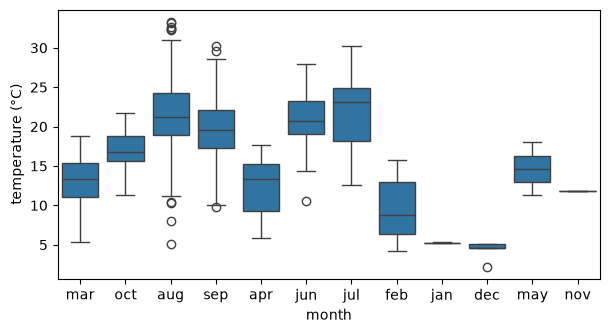

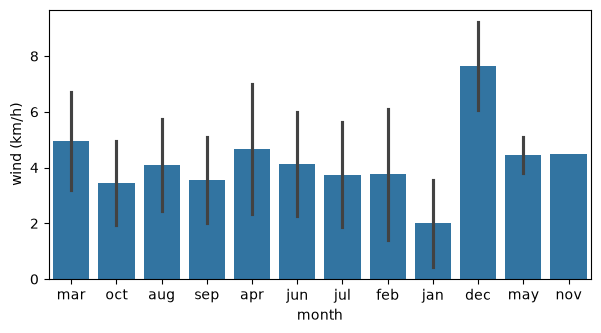

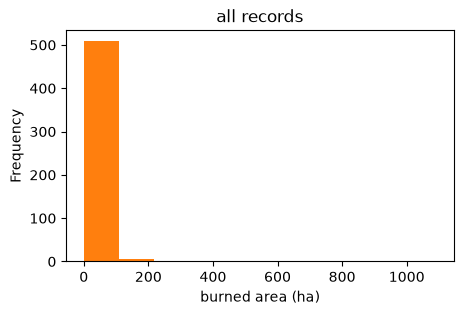

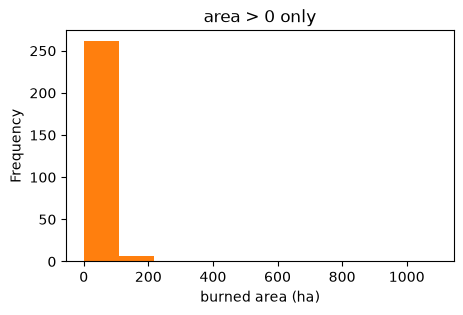

In [ ]:
# Pre-supplied: download the data file and cache it locally.
# You do not need to understand this cell yet — fetching data is covered in the
# reproducible-data-pipelines bonus subchapter.
import pooch

path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/forest_fires.csv",
    known_hash="sha256:0d6586a1fa52f55bef48578aef14eb97273f1e9330e1a53423df497a77065253",
    fname="forest_fires.csv",
    path=pooch.os_cache("mlees"),
)
fires = pd.read_csv(path)

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.boxplot(data=fires, x="month", y="temp", ax=ax)
ax.set_ylabel("temperature (°C)")
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(data=fires, x="month", y="wind", ax=ax, errorbar="sd")
ax.set_ylabel("wind (km/h)")
plt.show()

fig, ax = plt.subplots(figsize=(5, 3))
fires["area"].plot(ax=ax, kind="hist", color="tab:orange")
ax.set_xlabel("burned area (ha)")
ax.set_title("all records")
plt.show()

burned = fires[fires["area"] > 0.0]
fig, ax = plt.subplots(figsize=(5, 3))
burned["area"].plot(ax=ax, kind="hist", color="tab:orange")
ax.set_xlabel("burned area (ha)")
ax.set_title("area > 0 only")
plt.show()

# most fires burn ~0 ha, so the unfiltered histogram is one huge bin at zero; filtering to
# area > 0 is what actually shows the shape of the fires that did burn